<a href="https://colab.research.google.com/github/Orliluq/Inmersion_Agentes_de_IA_Alura_Clase_2/blob/main/Inmersi%C3%B3n_Agentes_de_IA_Alura_Clase_2_%2B_3_Orli.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
!pip install -q google-genai

In [18]:
from google.colab import userdata
import os

os.environ['GEMINI_API_KEY'] = userdata.get('GEMINI_API_KEY')

In [19]:
from google import genai

cliente = genai.Client()

In [20]:
respuesta = cliente.models.generate_content(
    model="gemini-2.5-flash",
    contents="Cuál es la capital y la ciudad más grande de Turquía?"
)

print(respuesta.text)

La capital de Turquía es **Ankara**.

La ciudad más grande y poblada de Turquía es **Estambul**.


In [21]:
from google.colab import files

os.makedirs("PDFs", exist_ok=True)
uploader = files.upload()

for archivo in uploader.keys():
  os.rename(archivo, f"PDFs/{archivo}")

Saving Carrarurquia_Reporte_Q1_2025.pdf to Carrarurquia_Reporte_Q1_2025.pdf
Saving Carrarurquia_Reporte_Q2_2025.pdf to Carrarurquia_Reporte_Q2_2025.pdf
Saving Carrarurquia_Reporte_Q3_2025.pdf to Carrarurquia_Reporte_Q3_2025.pdf
Saving Carrarurquia_Reporte_Q4_2025.pdf to Carrarurquia_Reporte_Q4_2025.pdf


In [22]:
!pip install -q langchain-community pypdf

In [23]:
from langchain_community.document_loaders import PyPDFLoader

In [24]:
documentos = []

for archivo2 in os.listdir("PDFs"):
  ruta = os.path.join("PDFs", archivo2)
  loader = PyPDFLoader(ruta)
  paginas = loader.load()
  documentos.extend(paginas)

In [25]:
documentos[0]

Document(metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creator': '(unspecified)', 'creationdate': '2026-02-13T13:49:44+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-02-13T13:49:44+00:00', 'subject': '(unspecified)', 'title': 'Carrarurquía - Reporte Q2 2025', 'trapped': '/False', 'source': 'PDFs/Carrarurquia_Reporte_Q2_2025.pdf', 'total_pages': 15, 'page': 0, 'page_label': '1'}, page_content='Carrarurquía\nReporte trimestral Q2 2025 (ficticio)\nPeriodo: 01/04/2025 - 30/06/2025\nMoneda: USD\n1\n Carrarurquía\n Reporte trimestral Q2 2025 · Viajes a Turquía (ficticio)\n Periodo: 01/04/2025 - 30/06/2025\n Moneda de referencia: dólares estadounidenses (USD)\nEste documento presenta resultados y aprendizajes ficticios del trimestre para Carrarurquía, una\nempresa de viajes especializada en experiencias en Turquía. Los datos, cifras y testimonios han sido\ncreados con fines demostrativos y no representan operaciones reales.\n Edición: Julio de 2025')

In [26]:
len(documentos)

60

In [27]:
!pip install -q langchain-text-splitters

In [28]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

divisor = RecursiveCharacterTextSplitter(
    chunk_size=400,
    chunk_overlap=40,
    separators=["\n\n", "\n", ". ", " ", ""]
)

fragmentos = divisor.split_documents(documentos)

In [29]:
fragmentos[67]

Document(metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creator': '(unspecified)', 'creationdate': '2026-02-13T13:49:44+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-02-13T13:49:44+00:00', 'subject': '(unspecified)', 'title': 'Carrarurquía - Reporte Q4 2025', 'trapped': '/False', 'source': 'PDFs/Carrarurquia_Reporte_Q4_2025.pdf', 'total_pages': 15, 'page': 10, 'page_label': '11'}, page_content='Riesgo\nProbabilidad\nImpacto\nMitigación principal\nSobrecupo hotelero en picos\nMedia\nAlto\nCupos firmes + lista de hoteles\nalternativos con precios\npre-negociados.\nIncidencias en traslados\ninternos\nMedia\nMedio\nMonitoreo de rutas + buffer de horarios\n+ partners con back-up.\nVariación de precios de\nproveedores\nAlta\nMedio\nCláusulas de ajuste y revisión\nquincenal de tarifas en temporada.')

In [30]:
!pip install -q langchain-google-genai faiss-cpu

In [31]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.vectorstores import FAISS

embeddings = GoogleGenerativeAIEmbeddings(
    model="models/gemini-embedding-001"
)

In [32]:
len(fragmentos)

172

In [33]:
import time

batch_size = 50
vectorstores = []

for i in range(0, len(fragmentos), batch_size):
    batch = fragmentos[i:i + batch_size]
    print(f"Procesando lote de fragmentos {i} a {i + len(batch)}")
    batch_vectorstore = FAISS.from_documents(
        documents=batch,
        embedding=embeddings
    )
    vectorstores.append(batch_vectorstore)
    # Wait for a bit to avoid hitting rate limits again
    time.sleep(45) # Sleep for 45 seconds to reset the quota

# Merge all batch vectorstores into a single vectorstore
if vectorstores:
    vectorstore = vectorstores[0]
    for j in range(1, len(vectorstores)):
        vectorstore.merge_from(vectorstores[j])
    print("Vectorstore final creado y fusionado con todos los fragmentos.")
else:
    print("No se crearon vectorstores. Verifica los fragmentos.")

Procesando lote de fragmentos 0 a 50
Procesando lote de fragmentos 50 a 100
Procesando lote de fragmentos 100 a 150
Procesando lote de fragmentos 150 a 172
Vectorstore final creado y fusionado con todos los fragmentos.


In [38]:
# vectorstore2 is no longer needed as all fragments are processed in a single vectorstore.
# This cell is now redundant.
# vectorstore2 = FAISS.from_documents(
#     documents=fragmentos[90:],
#     embedding=embeddings
# )

In [34]:
vectorstore.index.reconstruct(0)

array([-0.00143831,  0.00889298,  0.01531782, ...,  0.01553657,
       -0.00974552, -0.02190461], dtype=float32)

In [35]:
len(vectorstore.index.reconstruct(0))

3072

In [15]:
# Merging is no longer needed as all fragments are processed in a single vectorstore.
# This cell is now redundant.
# vectorstore.merge_from(vectorstore2)

In [36]:
consulta = "Cuál es el paquete de viajes más económico de Carrarurquía?"

resultados = vectorstore.similarity_search(
    consulta,
    k=7
)

for i in resultados:
  print(i)
  print("\n")

page_content='Carrarurquía
Reporte trimestral Q3 2025 (ficticio)
Periodo: 01/07/2025 - 30/09/2025
Moneda: USD
13
11. Apéndice A: Paquetes y tarifas de referencia
Lista simplificada de precios (USD)
Tarifas ficticias orientativas para paquetes populares. Los importes se muestran por persona en ocupación' metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creator': '(unspecified)', 'creationdate': '2026-02-13T13:49:44+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-02-13T13:49:44+00:00', 'subject': '(unspecified)', 'title': 'Carrarurquía - Reporte Q3 2025', 'trapped': '/False', 'source': 'PDFs/Carrarurquia_Reporte_Q3_2025.pdf', 'total_pages': 15, 'page': 12, 'page_label': '13'}


page_content='Carrarurquía
Reporte trimestral Q4 2025 (ficticio)
Periodo: 01/10/2025 - 31/12/2025
Moneda: USD
13
11. Apéndice A: Paquetes y tarifas de referencia
Lista simplificada de precios (USD)
Tarifas ficticias orientativas para paquetes populares. Los importes se muestran

In [37]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.2
)

retriever = vectorstore.as_retriever(
    search_kwargs={"k": 4}
)

In [38]:
def preguntar_rag(pregunta):
    """Busca contexto relevante en los documentos y genera una respuesta."""
    # Paso 1: Buscar los chunks más relevantes
    docs = retriever.invoke(pregunta)
    contexto = "\n\n---\n\n".join(doc.page_content for doc in docs)

    # Paso 2: Construir el prompt con el contexto encontrado
    prompt = f"""Eres un asistente experto que responde preguntas basándose ÚNICAMENTE
    en el contexto proporcionado. Si la información no está en el contexto,
    di que no tienes suficiente información.

    Contexto: {contexto}

    Pregunta: {pregunta}

    Respuesta:"""

    # Paso 3: Enviar al modelo y devolver la respuesta
    respuesta = llm.invoke(prompt)
    return respuesta.content

In [39]:
preguntar_rag("Dónde se mantuvo concentrado el mix de productos?")

'El mix de producto se mantuvo concentrado en circuitos combinados (Estambul + Capadocia).'

In [40]:
preguntar_rag("Cuántos mundiales de fútbol tiene Brasil?")

'No tengo suficiente información en el contexto proporcionado para responder cuántos mundiales de fútbol tiene Brasil.'

In [41]:
!pip install -q langgraph google-search-results markdown fpdf2

In [42]:
os.environ['SERPAPI_API_KEY'] = userdata.get('SERPAPI_API_KEY')

In [43]:
from langchain_community.utilities import SerpAPIWrapper

buscador = SerpAPIWrapper()

Construir el grafo con LangGraph


```
                    ┌─── "rag" ───→ [Buscar en documentos] ───┐
[START] → [Agente]                                         → [Generar Markdown] → END
                    └─── "web" ───→ [Buscar en la web] ───────┘
```

In [9]:
# This cell is now redundant as its content is moved to cell 4eq9ix2fK2i7.

In [50]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class AgentState(TypedDict):
  pregunta: str
  fuente: str
  contexto: str
  respuesta: str

def nodo_agente(state: AgentState):
  pregunta = state["pregunta"]

  prompt = f"""Eres un clasificador. Dada la siguiente pregunta, decide si se debe
  responder buscando en los DOCUMENTOS LOCALES (PDFs cargados) de la empresa Carrarurquía o
  informaciones más generales en la WEB (internet).
  Reglas:
  - Responde SOLO con la palabra 'RAG' si la pregunta se refiere al contenido de documentos cargados
  - Responde SOLO con la palabra 'Web' si la pregunta requiere información actualizada, de temas generales, de la web

  Pregunta: {pregunta}

  Respuesta (RAG o Web):"""

  respuesta = llm.invoke(prompt)

  fuente = respuesta.content.strip()

  if "RAG" in fuente:
    fuente = "RAG"
  else:
    fuente = "Web"

  print(f"El agente decidió la fuente {fuente}.")
  return {"fuente": fuente}

def nodo_rag(state: AgentState):
  contexto = preguntar_rag(state["pregunta"])
  return {"contexto": contexto}

def nodo_web(state: AgentState):
  contexto = buscador.run(state["pregunta"])
  return {"contexto": contexto}

def nodo_markdown(state: AgentState):
  prompt = f"""Eres un asistente experto. Genera una respuesta completa y bien
  formateada en Markdown basándote en el contexto proporcionado.

  Incluye: título (#), subtítulos (##), listas y negritas donde corresponda.
  Responde siempre en español.

  Contexto (fuente: {state["fuente"]}):
  {state["contexto"]}

  Pregunta: {state["pregunta"]}

  Respuesta en Markdown:"""

  respuesta = llm.invoke(prompt)
  return {"respuesta": respuesta.content}

def decidir_fuente(state: AgentState):
  if state["fuente"] == "RAG":
    return "RAG_elegido"
  elif state["fuente"] == "Web":
    return "Web_elegida"
  else:
    return "Error!"

grafo = StateGraph(AgentState)

grafo.add_node("Agente", nodo_agente)
grafo.add_node("RAG", nodo_rag)
grafo.add_node("Web", nodo_web)
grafo.add_node("Markdown", nodo_markdown)

grafo.add_edge(START, "Agente")
grafo.add_conditional_edges("Agente", decidir_fuente,
                            {"RAG_elegido": "RAG",
                             "Web_elegida": "Web"})
grafo.add_edge("RAG", "Markdown")
grafo.add_edge("Web", "Markdown")
grafo.add_edge("Markdown", END)

In [5]:
# This cell is now redundant as its content is moved to cell 4eq9ix2fK2i7.

In [6]:
# This cell is now redundant as its content is moved to cell 4eq9ix2fK2i7.

In [7]:
# This cell is now redundant as its content is moved to cell 4eq9ix2fK2i7.

In [8]:
# This cell is now redundant as its content is moved to cell 4eq9ix2fK2i7.

In [45]:
def decidir_fuente(state: AgentState):

  if state["fuente"] == "RAG":
    return "RAG_elegido"
  elif state["fuente"] == "Web":
    return "Web_elegida"
  else:
    return "Error!"

In [10]:
# This cell is now redundant as its content is moved to cell 4eq9ix2fK2i7.

In [51]:
agente = grafo.compile()

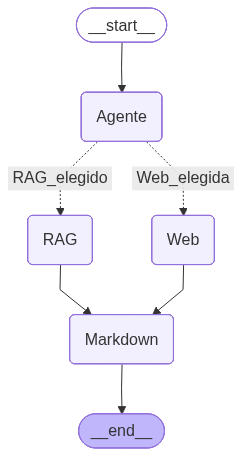

In [47]:
from IPython.display import Image, display

imagen = agente.get_graph().draw_mermaid_png()
display(Image(imagen))

In [52]:
def ejecutar_agente(pregunta):

  resultado = agente.invoke({
      "pregunta": pregunta,
      "fuente": "",
      "contexto": "",
      "respuesta": ""
  })

  respuesta_final = resultado["respuesta"]

  print("=" * 60)
  print(f"Fuente utilizada: {resultado["fuente"]}")
  print("=" * 60)
  print(f"Contexto utilizado: {resultado["contexto"]}")
  print("=" * 60)
  print(f"Respuesta final: {respuesta_final}")

  return respuesta_final

In [53]:
ejecutar_agente("Dónde se mantuvo concentrado el mix de productos?")

El agente decidió la fuente RAG.
Fuente utilizada: RAG
Contexto utilizado: El mix de producto se mantuvo concentrado en circuitos combinados (Estambul + Capadocia).
Respuesta final: # Concentración del Mix de Productos

## ¿Dónde se mantuvo concentrado el mix de productos?

Según el contexto proporcionado, el mix de productos se mantuvo concentrado en:

*   **Circuitos combinados**
    *   Estambul
    *   Capadocia


'# Concentración del Mix de Productos\n\n## ¿Dónde se mantuvo concentrado el mix de productos?\n\nSegún el contexto proporcionado, el mix de productos se mantuvo concentrado en:\n\n*   **Circuitos combinados**\n    *   Estambul\n    *   Capadocia'

In [54]:
ejecutar_agente("Cuántos mundiales de fútbol tiene Brasil?")

El agente decidió la fuente Web.
Fuente utilizada: Web
Contexto utilizado: ['La selección de fútbol de Brasil es la única que ha participado en todas las 22 ediciones de la Copa Mundial de Fútbol de la FIFA (habiendo sido sede en dos ...', 'Pese a sus 24 años sin títulos, Brasil sigue siendo la gran potencia en el panorama general de los Mundiales, en los que disputó 114 partidos, ...', 'Cuando BRASIL DABA MIEDO 🇧🇷 ⭐⭐⭐⭐⭐ Los 5 MUNDIALES de BRASIL La selección brasileña ha conquistado cinco Copas del Mundo y, desde hace más de 50 ...', 'En total, Brasil ha disputado 114 encuentros de la Copa Mundial; 76 de ellos se cuentan como victorias, 19 como derrotas, y firmó también 19 ...', 'Las primeras copas mundiales (1930-1950) · Primera Copa del Mundo: 1930 · Segunda Copa del Mundo: 1934 · Tercera Copa del Mundo: 1938 · Copa América 1949: el fin de ...', 'Es fácil. Tiene 2 copas del mundo. En total 4 campeonatos mundiales. En ésta publicación sólo cuentan copas del mundo.', 'Brasil es quien 

'# Títulos de Brasil en la Copa Mundial de la FIFA\n\nLa selección de fútbol de Brasil es la nación más exitosa en la historia de la Copa Mundial de la FIFA.\n\nBrasil ha conquistado un total de **cinco (5)** Copas del Mundo.\n\n## Detalles de los Títulos\n\nLos cinco campeonatos mundiales obtenidos por la selección brasileña fueron en los siguientes años:\n\n*   **1958**\n*   **1962**\n*   **1970**\n*   **1994**\n*   **2002**\n\nDesde su último título en 2002, Brasil no ha vuelto a levantar el trofeo.\n\n## Récord General en Mundiales\n\nAdemás de ser el equipo con más títulos, Brasil ostenta otros récords significativos:\n\n*   **Participaciones:** Es la única selección que ha participado en **todas las 22 ediciones** de la Copa Mundial de Fútbol de la FIFA.\n*   **Partidos Disputados:** Ha jugado un total de **114 encuentros** en la Copa Mundial.\n*   **Resultados:**\n    *   **Victorias:** 76 partidos\n    *   **Empates:** 19 partidos\n    *   **Derrotas:** 19 partidos\n\nA pesar d

# 🧠 Explicación del código paso a paso

Este código construye un agente de inteligencia artificial que puede responder preguntas usando dos fuentes:

- 📄 Documentos PDF (RAG)  
- 🌐 Internet (búsqueda web)  

Además, decide automáticamente cuál usar.

---

## 1. Configuración del modelo

Se instala y configura Gemini:

- Se define la API Key  
- Se crea un cliente (`genai.Client`)  
- Se prueba con una pregunta simple  

👉 Esto valida que el modelo funciona correctamente.

---

## 2. Carga de documentos

- Se suben archivos PDF  
- Se guardan en una carpeta  
- Se leen con `PyPDFLoader`  

👉 Resultado: los PDFs se convierten en texto procesable.

---

## 3. División del texto

- Se usa `RecursiveCharacterTextSplitter`  
- Se divide el contenido en fragmentos pequeños (chunks)  

👉 Esto permite trabajar con textos largos de forma eficiente.

---

## 4. Generación de embeddings

- Se usa `GoogleGenerativeAIEmbeddings`  
- Cada fragmento se convierte en un vector  

👉 Esto permite hacer búsquedas por significado (no por palabras exactas).

---

## 5. Creación del vector store

- Se usa `FAISS`  
- Se procesan los fragmentos en lotes  
- Se combinan en una sola base vectorial  

👉 Aquí se almacena el conocimiento del sistema.

---

## 6. Búsqueda semántica (RAG)

Cuando se hace una pregunta:

- Se buscan los fragmentos más relevantes  
- Se construye un contexto  
- Se envía al modelo  

👉 El modelo responde usando solo esa información.

---

## 7. Modelo de lenguaje

Se configura:

- `gemini-2.5-flash`  
- Baja temperatura (más precisión)  

👉 Se usa para generar respuestas.

---

## 8. Integración de búsqueda web

- Se usa `SerpAPI`  
- Permite consultar información externa  

👉 Complementa lo que no está en los PDFs.

---

## 9. Definición del flujo con LangGraph

Se construye un grafo con lógica de decisión:

**Pregunta → Agente → (RAG 🧠 | Web 🌐) → Respuesta en Markdown**

---

## 10. Lógica del agente

El nodo **Agente**:

- Analiza la pregunta  
- Decide:

  - `"RAG"` → usar documentos  
  - `"Web"` → usar internet  

---

## 11. Nodos del sistema

- **Agente** → decide la fuente  
- **RAG** → busca en PDFs  
- **Web** → busca en internet  
- **Markdown** → genera respuesta final  

---

## 12. Generación de respuesta

- Se construye un prompt con contexto  
- El modelo genera una respuesta en formato Markdown  

---

## 13. Ejecución

Función `ejecutar_agente`:

- Recibe una pregunta  
- Ejecuta todo el flujo  
- Muestra:
  - Fuente utilizada  
  - Contexto  
  - Respuesta final  

---

## 📌 Resultado

El sistema:

- Usa documentos internos cuando corresponde  
- Usa internet cuando es necesario  
- Decide automáticamente  
- Genera respuestas estructuradas  

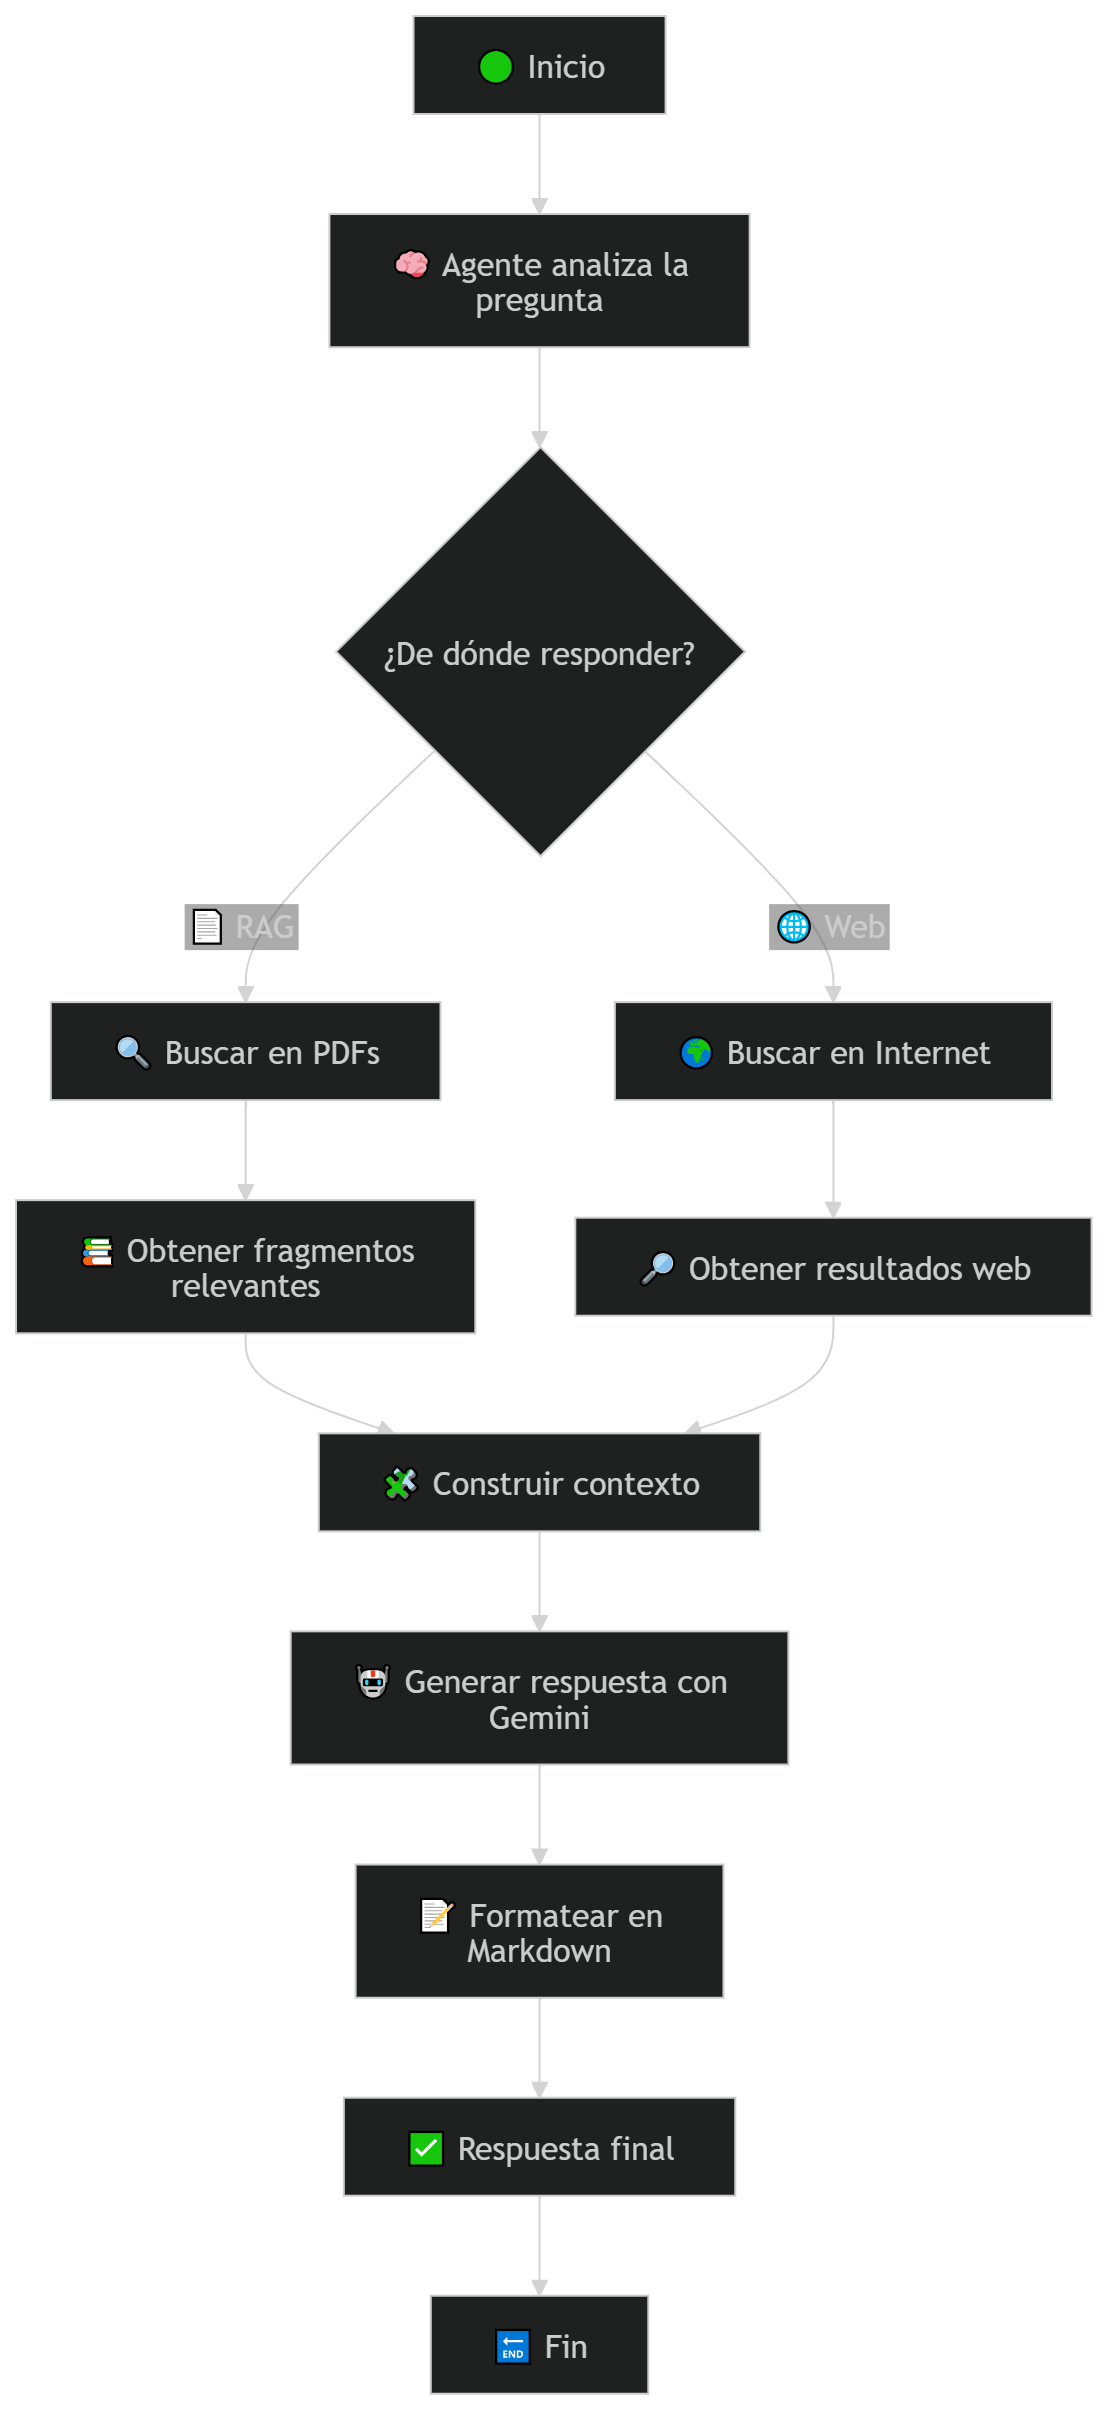

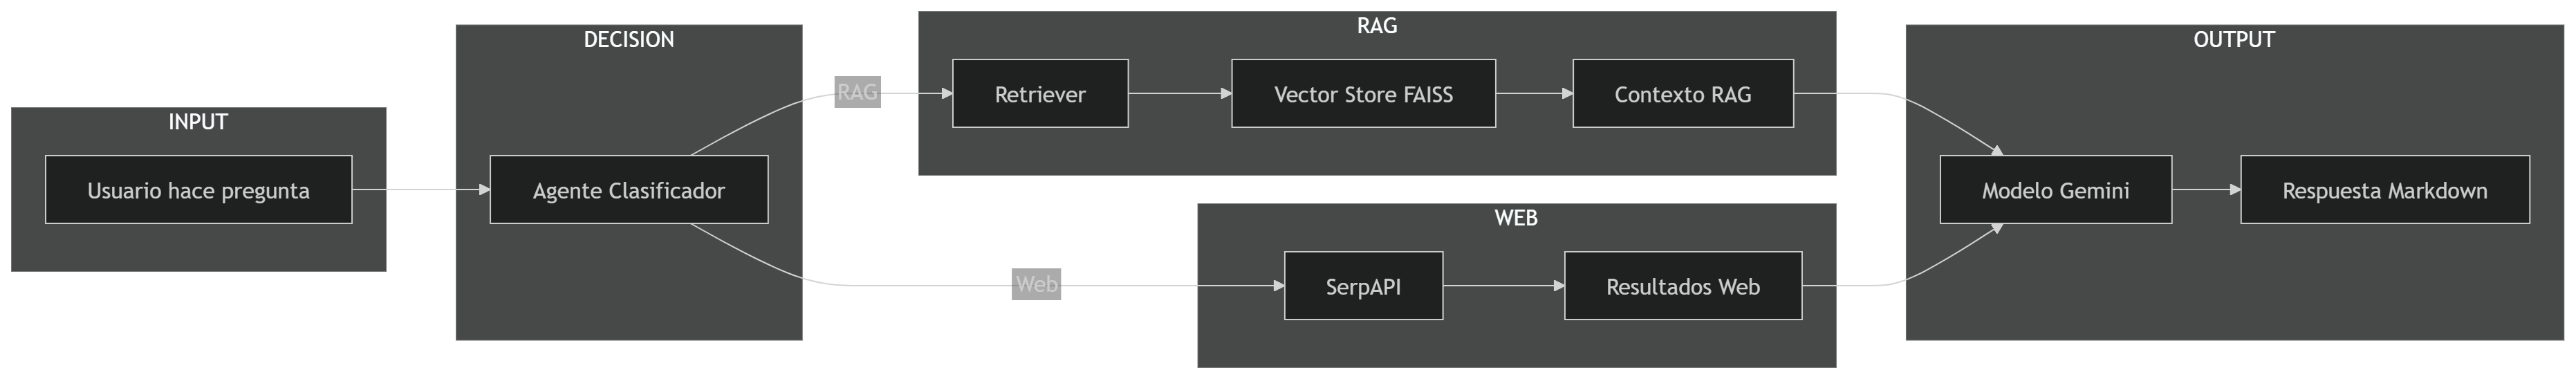

## 🧠 **Cómo explicarlo**

El agente primero decide si responder con conocimiento interno (RAG) o externo (web).
Luego construye contexto y genera una respuesta estructurada con el modelo.

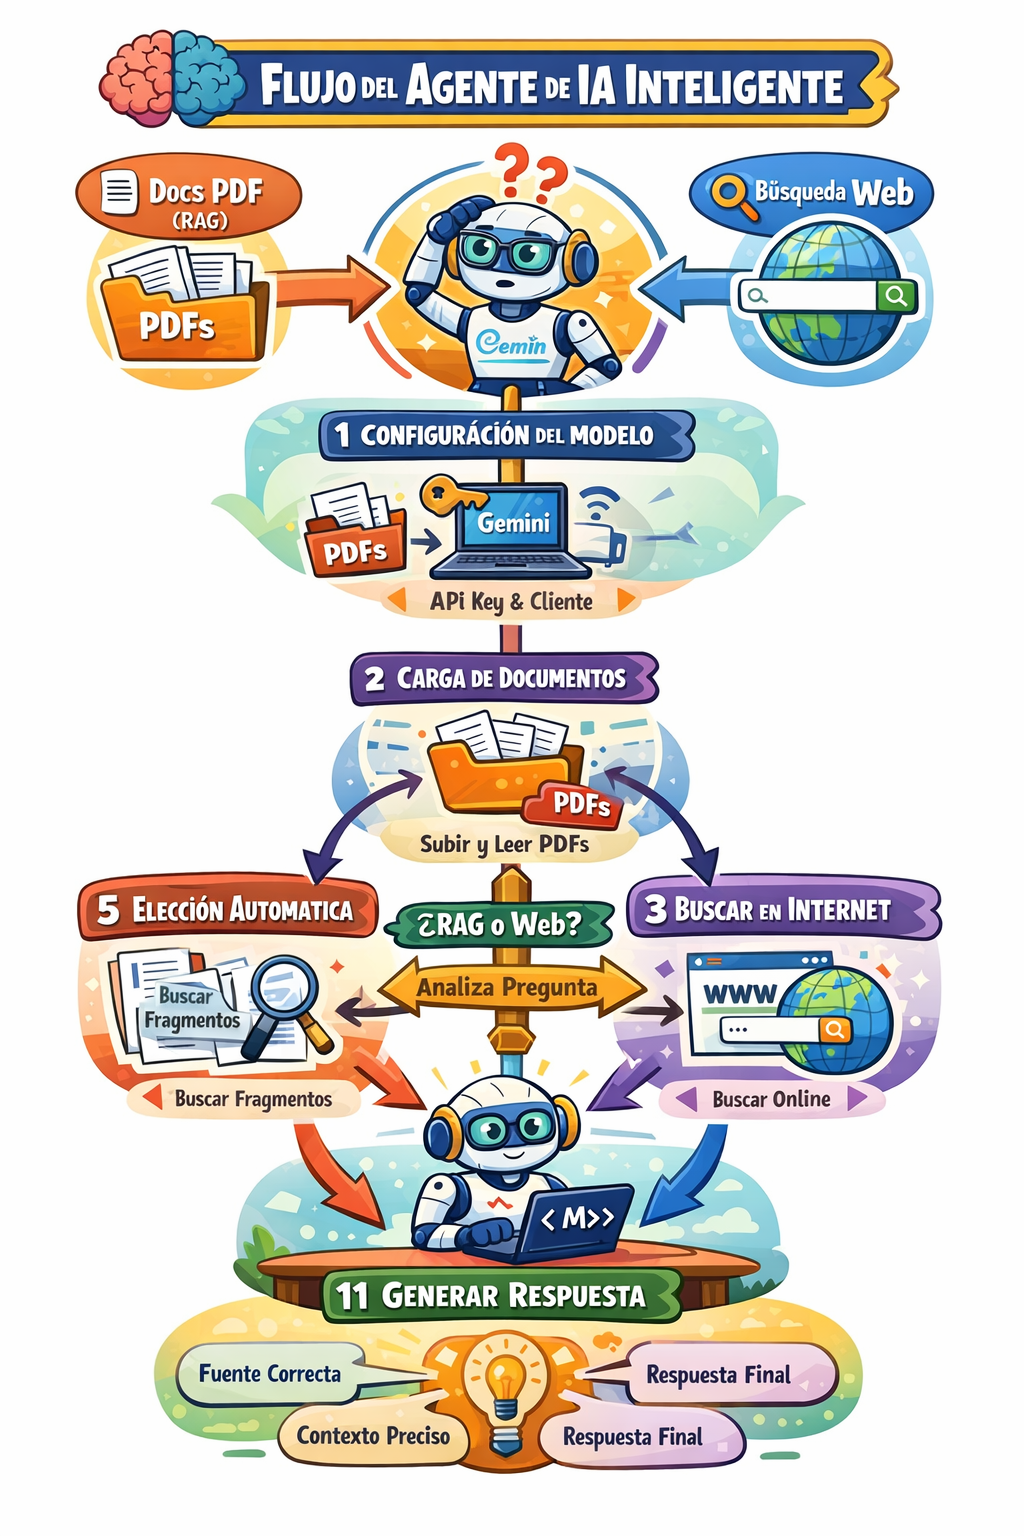